In [4]:
import pandas as pd
import numpy as np

In [5]:
import os
os.chdir("/workspaces/group-project-team2/checkpoint/data_acquisition/")

## Data Import
Loading the BRFSS (Behavioral Risk Factor Surveillance System) 2024 dataset from a SAS file format (.XPT). This dataset contains health-related survey data.

In [6]:
brfss1 = pd.read_parquet("BRFSS_2024_1.parquet.gzip")
brfss2 =  pd.read_parquet("BRFSS_2024_2.parquet.gzip")

## Initial Data Inspection and Merging
Displaying basic information about the dataset including:
- Number of rows and columns
- Data types of each column
- Memory usage
- Non-null counts

In [7]:
brfss1.info()
brfss2.info()

<class 'pandas.DataFrame'>
RangeIndex: 228835 entries, 0 to 228834
Columns: 301 entries, _STATE to _AIDTST4
dtypes: float64(296), object(5)
memory usage: 525.5+ MB
<class 'pandas.DataFrame'>
RangeIndex: 228835 entries, 228835 to 457669
Columns: 301 entries, _STATE to _AIDTST4
dtypes: float64(296), object(5)
memory usage: 525.5+ MB


In [8]:
brfss = pd.concat([brfss1, brfss2], axis = 0)

In [9]:
brfss.info()

<class 'pandas.DataFrame'>
RangeIndex: 457670 entries, 0 to 457669
Columns: 301 entries, _STATE to _AIDTST4
dtypes: float64(296), object(5)
memory usage: 1.0+ GB


## Dataset Overview
Displaying statistical summary of the dataset:
- Count of non-null values
- Mean, standard deviation
- Minimum, maximum values
- Quartile distributions (25%, 50%, 75%)

In [10]:
brfss.describe()

,_STATE,FMONTH,DISPCODE,_PSU,CTELENM1,PVTRESD1,COLGHOUS,STATERE1,CELPHON1,LADULT1,...,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
count,457670.000000,457670.000000,457670.000000,4.576700e+05,81730.0,81730.000000,14.0,81730.0,81730.0,81730.000000,...,393433.000000,406226.000000,457670.000000,4.576690e+05,457670.000000,4.576700e+05,457670.000000,179344.000000,179344.000000,414178.000000
mean,30.823537,6.426995,1118.669784,2.024007e+09,1.0,1.000171,1.0,1.0,2.0,1.001835,...,3.420252,8.468687,2.196764,1.000599e+02,1.948965,1.044393e+04,1.869063,2.336850,2.462223,1.999684
std,15.939364,3.356938,38.966920,7.488291e+03,0.0,0.013087,0.0,0.0,0.0,0.042801,...,0.792956,1.892208,2.226566,2.613717e+02,2.418721,3.016653e+04,2.414067,2.602255,2.814818,1.665037
min,1.000000,1.000000,1100.000000,2.024000e+09,1.0,1.000000,1.0,1.0,2.0,1.000000,...,1.000000,1.000000,1.000000,5.397605e-79,1.000000,5.397605e-79,1.000000,1.000000,1.000000,1.000000
25%,18.000000,4.000000,1100.000000,2.024002e+09,1.0,1.000000,1.0,1.0,2.0,1.000000,...,3.000000,9.000000,1.000000,5.397605e-79,1.000000,5.397605e-79,1.000000,1.000000,1.000000,1.000000
50%,31.000000,7.000000,1100.000000,2.024005e+09,1.0,1.000000,1.0,1.0,2.0,1.000000,...,4.000000,9.000000,2.000000,3.000000e+00,1.000000,4.700000e+01,1.000000,1.000000,1.000000,2.000000
75%,44.000000,9.000000,1100.000000,2.024008e+09,1.0,1.000000,1.0,1.0,2.0,1.000000,...,4.000000,9.000000,2.000000,2.900000e+01,1.000000,4.670000e+02,1.000000,2.000000,2.000000,2.000000
max,78.000000,12.000000,1200.000000,2.024044e+09,1.0,2.000000,1.0,1.0,2.0,2.000000,...,4.000000,9.000000,9.000000,9.000000e+02,9.000000,9.990000e+04,9.000000,9.000000,9.000000,9.000000


In [11]:
brfss.head()

,_STATE,FMONTH,IDATE,IMONTH,IDAY,IYEAR,DISPCODE,SEQNO,_PSU,CTELENM1,...,_LCSCTSN,_LCSPSTF,DRNKANY6,DROCDY4_,_RFBING6,_DRNKWK3,_RFDRHV9,_FLSHOT7,_PNEUMO3,_AIDTST4
0,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000001',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,2.0,2.0
1,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000002',2.024000e+09,1.0,...,4.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
2,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000003',2.024000e+09,1.0,...,4.0,2.0,1.0,1.000000e+02,2.0,1.400000e+03,1.0,NaN,NaN,2.0
3,1.0,2.0,b'02282024',b'02',b'28',b'2024',1100.0,b'2024000004',2.024000e+09,1.0,...,NaN,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,1.0,1.0,2.0
4,1.0,2.0,b'02212024',b'02',b'21',b'2024',1100.0,b'2024000005',2.024000e+09,1.0,...,3.0,9.0,2.0,5.397605e-79,1.0,5.397605e-79,1.0,NaN,NaN,2.0


## Column Names Inspection
Displaying all column names in the dataset to identify available features for analysis.

In [12]:
for col in brfss.columns:
    print(col)

_STATE
FMONTH
IDATE
IMONTH
IDAY
IYEAR
DISPCODE
SEQNO
_PSU
CTELENM1
PVTRESD1
COLGHOUS
STATERE1
CELPHON1
LADULT1
NUMADULT
RESPSLC1
LANDSEX3
SAFETIME
CTELNUM1
CELLFON5
CADULT1
CELLSEX3
PVTRESD3
CCLGHOUS
CSTATE1
LANDLINE
HHADULT
SEXVAR
GENHLTH
PHYSHLTH
MENTHLTH
POORHLTH
PRIMINS2
PERSDOC3
MEDCOST1
CHECKUP1
EXERANY2
LASTDEN4
RMVTETH4
CVDINFR4
CVDCRHD4
CVDSTRK3
ASTHMA3
ASTHNOW
CHCSCNC1
CHCOCNC1
CHCCOPD3
ADDEPEV3
CHCKDNY2
HAVARTH4
DIABETE4
DIABAGE4
MARITAL
EDUCA
RENTHOM1
NUMHHOL4
NUMPHON4
CPDEMO1C
VETERAN3
EMPLOY1
CHILDREN
INCOME3
PREGNANT
WEIGHT2
HEIGHT3
DEAF
BLIND
DECIDE
DIFFWALK
DIFFDRES
DIFFALON
HADMAM
HOWLONG
CERVSCRN
CRVCLCNC
CRVCLPAP
CRVCLHPV
HADHYST2
HADSIGM4
COLNSIGM
COLNTES1
SIGMTES1
LASTSIG4
COLNCNCR
VIRCOLO1
VCLNTES2
SMALSTOL
STOLTEST
STOOLDN2
BLDSTFIT
SDNATES1
SMOKE100
SMOKDAY2
USENOW3
ECIGNOW3
LCSFIRST
LCSNUMCG
LCSCTSC1
LCSSCNCR
LCSCTWHN
ALCDAY4
AVEDRNK4
DRNK3GE5
MAXDRNKS
FLUSHOT7
FLSHTMY3
IMFVPLA5
PNEUVAC4
HIVTST7
HIVTSTD3
HIVRISK5
PDIABTS1
PREDIAB2
DIABTYPE
INSULIN1
CHKHEMO3
EY

In [13]:
columns_list = brfss.columns.tolist()
print(columns_list)

['_STATE', 'FMONTH', 'IDATE', 'IMONTH', 'IDAY', 'IYEAR', 'DISPCODE', 'SEQNO', '_PSU', 'CTELENM1', 'PVTRESD1', 'COLGHOUS', 'STATERE1', 'CELPHON1', 'LADULT1', 'NUMADULT', 'RESPSLC1', 'LANDSEX3', 'SAFETIME', 'CTELNUM1', 'CELLFON5', 'CADULT1', 'CELLSEX3', 'PVTRESD3', 'CCLGHOUS', 'CSTATE1', 'LANDLINE', 'HHADULT', 'SEXVAR', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'POORHLTH', 'PRIMINS2', 'PERSDOC3', 'MEDCOST1', 'CHECKUP1', 'EXERANY2', 'LASTDEN4', 'RMVTETH4', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'ASTHNOW', 'CHCSCNC1', 'CHCOCNC1', 'CHCCOPD3', 'ADDEPEV3', 'CHCKDNY2', 'HAVARTH4', 'DIABETE4', 'DIABAGE4', 'MARITAL', 'EDUCA', 'RENTHOM1', 'NUMHHOL4', 'NUMPHON4', 'CPDEMO1C', 'VETERAN3', 'EMPLOY1', 'CHILDREN', 'INCOME3', 'PREGNANT', 'WEIGHT2', 'HEIGHT3', 'DEAF', 'BLIND', 'DECIDE', 'DIFFWALK', 'DIFFDRES', 'DIFFALON', 'HADMAM', 'HOWLONG', 'CERVSCRN', 'CRVCLCNC', 'CRVCLPAP', 'CRVCLHPV', 'HADHYST2', 'HADSIGM4', 'COLNSIGM', 'COLNTES1', 'SIGMTES1', 'LASTSIG4', 'COLNCNCR', 'VIRCOLO1', 'VCLNTES2', 'SMALST

## Selecting Relevant Features


- **_AGE_G (Age Group)**: Essential demographic variable that allows for age-stratified analysis and controls for age-related health patterns in outcome assessment.

- **_SEX (Sex)**: Key demographic predictor as health outcomes and risk factors often differ significantly between males and females.

- **_BMI5 (Body Mass Index)**: Direct quantitative measure of body weight relative to height, crucial for assessing weight-related health risks.

- **_RFBMI5 (Obese)**: Binary obesity classification derived from BMI, serving as a primary outcome variable for identifying obesity prevalence and risk factors.

- **HTM4 (Height)**: Anthropometric measure needed for BMI calculations and body composition assessments.

- **_TOTINDA (Physical Activity)**: Important behavioral variable; physical activity is a known protective factor against obesity and chronic diseases.

- **WTKG3 (Weight)**: Direct weight measurement in kilograms, essential for BMI computation and weight status classification.

- **_RFSMOK3 (Smoking Status)**: Significant lifestyle factor that influences metabolism, weight patterns, and overall health outcomes.

- **_RFDRHV9 (Heavy Drinker)**: Behavioral risk factor; heavy alcohol consumption is associated with various health outcomes including weight gain.

- **_EDUCAG (Education Level)**: Socioeconomic indicator that often correlates with health literacy, lifestyle choices, and health outcomes.

- **_INCOMG1 (Income Category)**: Socioeconomic variable affecting access to healthcare, healthy food options, and health-related resources.

## Primary Outcomes
- Obesity prevalence and classification
- Identification of demographic and behavioral risk factors associated with obesity
- Understanding socioeconomic disparities in weight-related health outcomes


In [14]:
cols = ["_AGE_G", "_SEX","_BMI5","_RFBMI5","HTM4", "_TOTINDA","WTKG3", "_RFSMOK3",
        "_RFDRHV9","_EDUCAG" , "_INCOMG1"]
data = brfss[cols]

## Renaming Variable Names 

In [15]:

# Renaming Variable Names

data = data.rename(columns={ "_SEX": "Sex",
                           "_BMI5": "BMI",
                           "_AGE_G": "Age_group",
                           "_RFBMI5": "Obese",
                           "HTM4": "Height(m)",
                           "_TOTINDA": "Physical_Activity",
                           "WTKG3": "Weight(kg)",
                           "_RFSMOK3": "Smoker",
                           "_RFDRHV9": "Heavy_Drinker",
                           "_EDUCAG": "Education_level",
                           "_INCOMG1": "Income_Cat"
                         })
data.columns

Index(['Age_group', 'Sex', 'BMI', 'Obese', 'Height(m)', 'Physical_Activity',
       'Weight(kg)', 'Smoker', 'Heavy_Drinker', 'Education_level',
       'Income_Cat'],
      dtype='str')

In [16]:
data.head()

,Age_group,Sex,BMI,Obese,Height(m),Physical_Activity,Weight(kg),Smoker,Heavy_Drinker,Education_level,Income_Cat
0,6.0,2.0,2249.0,1.0,163.0,1.0,5942.0,1.0,1.0,2.0,9.0
1,6.0,1.0,2583.0,2.0,178.0,1.0,8165.0,1.0,1.0,4.0,7.0
2,5.0,1.0,2253.0,1.0,198.0,1.0,8845.0,2.0,1.0,3.0,9.0
3,6.0,1.0,2509.0,2.0,173.0,1.0,7484.0,1.0,1.0,4.0,4.0
4,4.0,1.0,1977.0,1.0,173.0,2.0,5897.0,1.0,1.0,3.0,2.0


# Recoding Variables from Numeric to Categorical Format
- Converting Income Categories from Numeric Codes to Ordered Factor Labels:
 Preserves the natural hierarchy of income levels for appropriate statistical analysis.

- Transforming Education Level from Numeric Values to Ordered Categorical Variable:
 Captures the progressive nature of educational attainment from no diploma through college graduation.

- Recoding Heavy Drinker Status from Numeric to Categorical Format:
 Improves interpretability by using descriptive "Yes"/"No" labels for this binary variable.

- Converting Smoking Status from Numeric Codes to Binary Categories:
  Makes the data self-documenting and prevents numeric codes from being misinterpreted as quantitative.

- Mapping Physical Activity Variable from Numeric to Descriptive Categories:Provides clear, descriptive labels that eliminate ambiguity in understanding activity status.

- Transforming Age Group from Numeric Codes to Ordered Categorical Levels: Maintains the natural age progression for demographic analyses and stratification.

- Converting Sex Variable from Numeric to Character Labels: Eliminates the need for codebook reference by using immediately interpretable labels.

- Recoding Obesity Status from Numeric to Binary Categorical Format: Clearly communicates health status using straightforward "Yes"/"No" categories.

In [17]:

# Mapping Values In Categorical Variables ... Changing them From Numeric to Categories

# Converting  income var to integer
data["Income_Cat"] = data["Income_Cat"].astype("Int64")

# Ordered income categories
income_order = [
        "Less than $15,000",
        "$15,000 < $25,000",
        "$25,000 < $35,000",
        "$35,000 < $50,000",
        "$50,000 < $100,000",
        "$100,000 < $200,000",
        "$200,000 or more",
        "Missing/Don’t know",
]

# Replacing numeric codes with categories 
data["Income_Cat"] = pd.Categorical(
    data["Income_Cat"].map({
        1: "Less than $15,000",
        2: "$15,000 < $25,000",
        3: "$25,000 < $35,000",
        4: "$35,000 < $50,000",
        5: "$50,000 < $100,000",
        6: "$100,000 < $200,000",
        7: "$200,000 or more",
        9: np.nan
    }),
    categories = income_order,
    ordered = True
)

In [18]:

# Converting  education variable to integer 
data["Education_level"] = data["Education_level"].astype("Int64")

# Ordered education categories
education_order = [
    "Did not graduate High School",
    "Graduated High School",
    "Attended College or Technical School",
    "Graduated from College or Technical School",
    "Don’t know/Not sure/Missing"
]

# Replace numeric codes with categories and create an ordered categorical
data["Education_level"] = pd.Categorical(
    data["Education_level"].map({
        1: "Did not graduate High School",
        2: "Graduated High School",
        3: "Attended College or Technical School",
        4: "Graduated from College or Technical School",
        9: np.nan
    }),
    categories=education_order,
    ordered=True
)

In [19]:

# Converting the column to integer
data["Heavy_Drinker"] = data["Heavy_Drinker"].astype("Int64")

# Map numeric codes 
data["Heavy_Drinker"] = pd.Categorical(
    data["Heavy_Drinker"].map({
        1: "No",
        2: "Yes",
        9: np.nan
    })
)

In [20]:
# Converting  column to integer 
data["Smoker"] = data["Smoker"].astype("Int64")

# Map numeric codes to categor
data["Smoker"] = pd.Categorical(
    data["Smoker"].map({
        1: "No",
        2: "Yes",
        9: np.nan 
    })
)


In [21]:
# Converting column to integer 
data["Obese"] = data["Obese"].astype("Int64")

# Mapping numeric codes to categories
data["Obese"] = data["Obese"].map({
    1: "No",
    2: "Yes",
    9: np.nan 
})

In [22]:
# Converting to integer 
data["Sex"] = data["Sex"].astype("Int64")

# Mapping numeric codes to categories
data["Sex"] = data["Sex"].map({
    1: "Male",
    2: "Female"
})

In [23]:
# Converting column to integer 
data["Age_group"] = data["Age_group"].astype("Int64")

# Defining the ordered categories
age_order = [
    "Age 18 to 24",
    "Age 25 to 34",
    "Age 35 to 44",
    "Age 45 to 54",
    "Age 55 to 64",
    "Age 65 or older"
]

# Map numeric codes to categories 
data["Age_group"] = pd.Categorical(
    data["Age_group"].map({
        1: "Age 18 to 24",
        2: "Age 25 to 34",
        3: "Age 35 to 44",
        4: "Age 45 to 54",
        5: "Age 55 to 64",
        6: "Age 65 or older"
    }),
    categories=age_order,
    ordered=True
)

In [24]:

# Converting column to integer 
data["Physical_Activity"] = data["Physical_Activity"].astype("Int64")

data["Physical_Activity"] = pd.Categorical(
    data["Physical_Activity"].map({
        1: "Had physical activity or exercise",
        2: "No physical activity or exercise in last 30 days",
        9: np.nan
    })
)

In [25]:
data.describe(include = "category")

,Age_group,Physical_Activity,Smoker,Heavy_Drinker,Education_level,Income_Cat
count,457670,456355,425648,410972,455307,370247
unique,6,2,2,2,4,7
top,Age 65 or older,Had physical activity or exercise,No,No,Graduated from College or Technical School,"$50,000 < $100,000"
freq,172826,350061,378554,386812,191549,112409


In [26]:
data.describe()

,BMI,Height(m),Weight(kg)
count,414633.000000,433610.000000,421278.000000
mean,2855.680093,170.165995,8300.484516
std,658.616131,10.822765,2141.833796
min,1200.000000,91.000000,2268.000000
25%,2414.000000,163.000000,6804.000000
50%,2744.000000,170.000000,8074.000000
75%,3175.000000,178.000000,9525.000000
max,9984.000000,241.000000,29030.000000


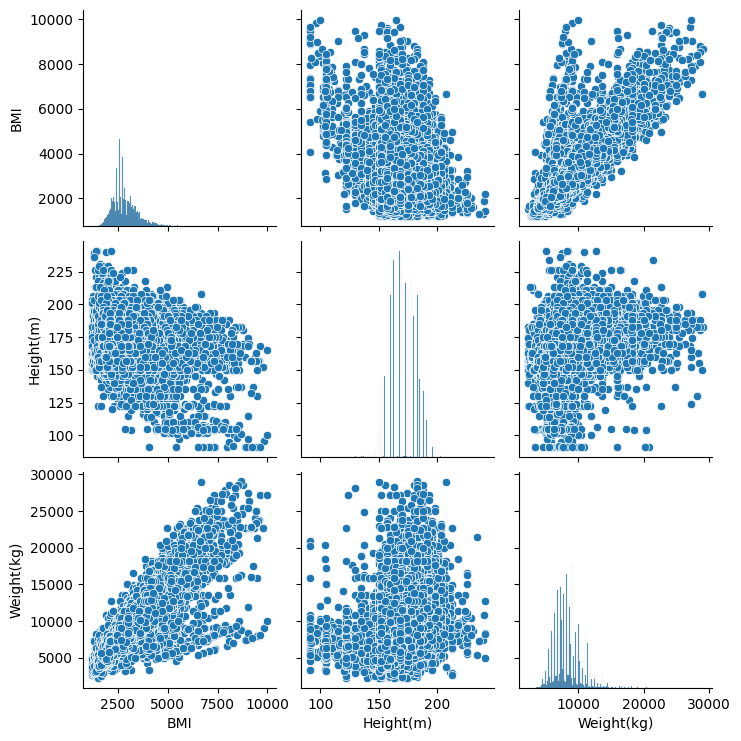

In [28]:
import seaborn as sns

# computing correlation 
data.corr(numeric_only=True)

sns.pairplot(data)


## Distribution Visualization
Creating histograms for all numerical variables in the dataset to:
- Understand the distribution of each feature
- Identify potential outliers or skewness
- Visualize data patterns before modeling

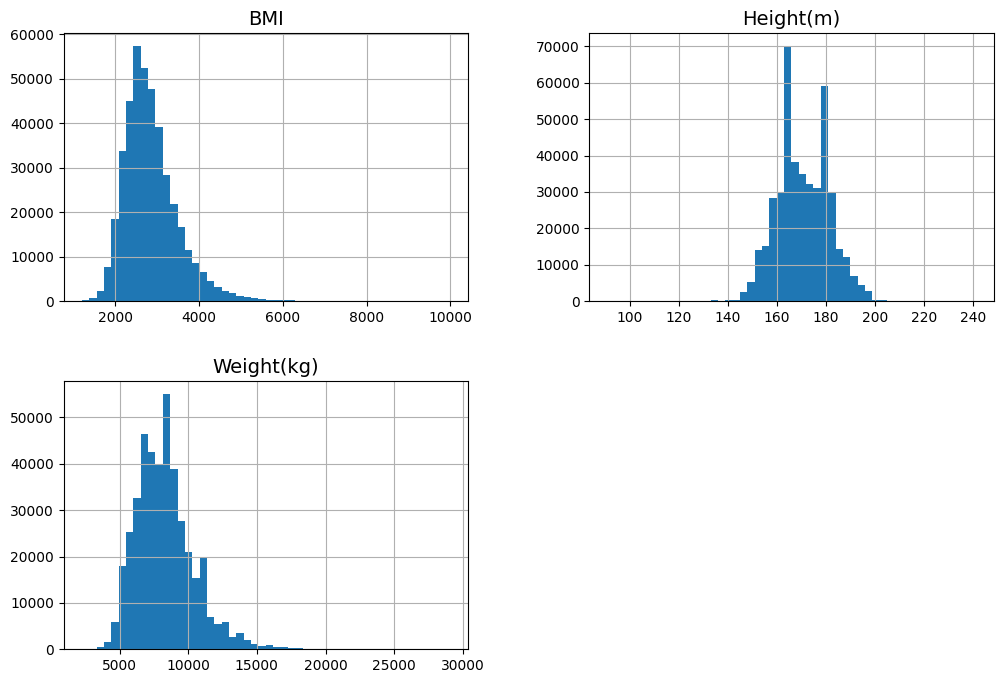

In [29]:
import matplotlib.pyplot as plt

# Visualizing Variables Distributions

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

data.hist(bins=50, figsize=(12, 8))
plt.show()

## Categorical Variable Analysis
Displaying frequency counts for all categorical variables to understand:
- Class distribution and balance
- Most common categories
- Potential data quality issues

In [30]:
cat_vars = ["Age_group", "Sex", "Obese" , "Physical_Activity", "Smoker", "Heavy_Drinker","Education_level", "Income_Cat"]

for var in cat_vars:
    print(data[var].value_counts())
    print("\n")

Age_group
Age 65 or older    172826
Age 55 to 64        80280
Age 45 to 54        64458
Age 35 to 44        60418
Age 25 to 34        49994
Age 18 to 24        29694
Name: count, dtype: int64


Sex
Female    240163
Male      217507
Name: count, dtype: int64


Obese
Yes    286203
No     128430
Name: count, dtype: int64


Physical_Activity
Had physical activity or exercise                   350061
No physical activity or exercise in last 30 days    106294
Name: count, dtype: int64


Smoker
No     378554
Yes     47094
Name: count, dtype: int64


Heavy_Drinker
No     386812
Yes     24160
Name: count, dtype: int64


Education_level
Graduated from College or Technical School    191549
Attended College or Technical School          120732
Graduated High School                         115877
Did not graduate High School                   27149
Don’t know/Not sure/Missing                        0
Name: count, dtype: int64


Income_Cat
$50,000 < $100,000     112409
$100,000 < $200,000     82453
$

## Missing Values Analysis
Conducting a comprehensive missing data assessment:
- Counting total observations
- Identifying missing values per column
- Displaying rows with any missing data to understand missingness patterns

In [31]:
data.info() # 457669 observations

# Missing values counts by columns
data.isna().sum()

# Rows with missing values
data[data.isna().any(axis=1)]

<class 'pandas.DataFrame'>
RangeIndex: 457670 entries, 0 to 457669
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   Age_group          457670 non-null  category
 1   Sex                457670 non-null  str     
 2   BMI                414633 non-null  float64 
 3   Obese              414633 non-null  str     
 4   Height(m)          433610 non-null  float64 
 5   Physical_Activity  456355 non-null  category
 6   Weight(kg)         421278 non-null  float64 
 7   Smoker             425648 non-null  category
 8   Heavy_Drinker      410972 non-null  category
 9   Education_level    455307 non-null  category
 10  Income_Cat         370247 non-null  category
dtypes: category(6), float64(3), str(2)
memory usage: 23.5 MB


,Age_group,Sex,BMI,Obese,Height(m),Physical_Activity,Weight(kg),Smoker,Heavy_Drinker,Education_level,Income_Cat
0,Age 65 or older,Female,2249.0,No,163.0,Had physical activity or exercise,5942.0,No,No,Graduated High School,NaN
2,Age 55 to 64,Male,2253.0,No,198.0,Had physical activity or exercise,8845.0,Yes,No,Attended College or Technical School,NaN
7,Age 65 or older,Female,3649.0,Yes,170.0,No physical activity or exercise in last 30 days,10569.0,No,No,Attended College or Technical School,NaN
22,Age 65 or older,Female,2769.0,Yes,178.0,No physical activity or exercise in last 30 days,8754.0,No,No,Attended College or Technical School,NaN
23,Age 65 or older,Male,2455.0,No,183.0,No physical activity or exercise in last 30 days,8210.0,No,No,Attended College or Technical School,NaN
...,...,...,...,...,...,...,...,...,...,...,...
457659,Age 65 or older,Female,2334.0,No,163.0,Had physical activity or exercise,6169.0,No,No,Graduated High School,NaN
457660,Age 55 to 64,Male,3632.0,Yes,168.0,Had physical activity or exercise,10206.0,NaN,NaN,Graduated High School,"$25,000 < $35,000"
457662,Age 55 to 64,Male,3067.0,Yes,168.0,No physical activity or exercise in last 30 days,8618.0,NaN,No,Graduated from College or Technical School,"$50,000 < $100,000"
457665,Age 65 or older,Male,NaN,NaN,NaN,Had physical activity or exercise,NaN,NaN,NaN,Did not graduate High School,NaN


## Data Preprocessing